# Euler-Maruyama Convergence Test

## Functions

The two main functions that will be used are shown below. They map directly to the math developed in the documentation, and implement the exact, analytical solution, as well as the Euler-Maruyama discretization. The normal fluctuations matrix $W$ is taken as a parameter so the same normal samples can be used for both functions, in order to test the strong and weak convergence order. The two next fumctions then calculate the weak and strong errors, using calls to the first two functions.

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def analytical_GBM(mu, sigma, S0, T, W):
    """Evaluates the exact solution for the GBM SDE"""
    n_sims, n_steps = np.shape(W)

    paths = np.zeros((n_sims, n_steps + 1))
    paths[:, 0] = S0

    dt = T/n_steps
    W_t = np.cumsum(W, axis=1)

    for i in range(n_steps):
        t = (i + 1) * dt
        paths[:,i+1] = S0 * np.exp((mu-0.5 * sigma**2) * t + sigma * W_t[:,i])

    return paths

def euler_maruyama_GBM(mu, sigma, S0, T, W):
    """Simulates GBM paths using the Euler-Maruyama method."""
    n_sims, n_steps = np.shape(W)

    paths = np.zeros((n_sims, n_steps + 1))
    paths[:, 0] = S0

    dt = T/n_steps

    for i in range(n_steps):
        dW = W[:,i]
        paths[:, i+1] = paths[:, i] + mu * paths[:, i] * dt + sigma * paths[:, i] * dW
    
    return paths

def strong_error(mu, sigma, S0, T, W):
    """Calculates the strong error at the final time T."""
    exact = analytical_GBM(mu, sigma, S0, T, W)
    numerical = euler_maruyama_GBM(mu, sigma, S0, T, W)

    error = np.mean(np.abs(exact[:, -1] - numerical[:, -1]))

    return error


def weak_error(mu, sigma, S0, T, W, payoff=lambda x: x):
    """Calculates the weak error at the final time T."""
    exact = analytical_GBM(mu, sigma, S0, T, W)
    numerical = euler_maruyama_GBM(mu, sigma, S0, T, W)

    exact_payoff = payoff(exact[:, -1])
    numerical_payoff = payoff(numerical[:, -1])

    error = np.abs(np.mean(exact_payoff) - np.mean(numerical_payoff))

    return error

## Simulating paths

By changing the parameters below, several paths for the GBM SDE can be run, allowing for quick qualitative comparison.

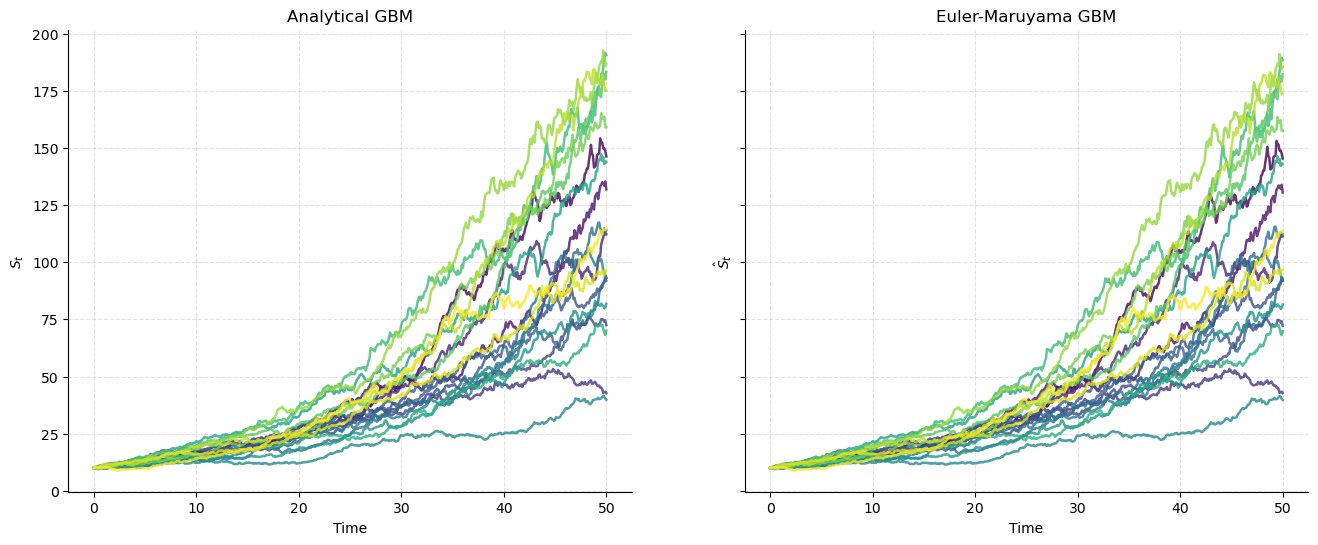

In [65]:
# Parameters
mu = 0.05
sigma = 0.05
S0 = 10
T = 50

dt = 0.1
n_sims = 20

# Auxiliary values
n_steps = int(T / dt)
W = np.random.normal(0, np.sqrt(dt), (n_sims, n_steps))
x = np.linspace(0, T, n_steps + 1)

St = analytical_GBM(mu, sigma, S0, T, W)
St_num = euler_maruyama_GBM(mu, sigma, S0, T, W)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, n_sims))

# Analytical GBM
for i, color in enumerate(colors):
    axes[0].plot(x, St[i], color=color, alpha=0.8, linewidth=1.8)

axes[0].set_title("Analytical GBM")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("$S_t$")
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Euler-Maruyama GBM
for i, color in enumerate(colors):
    axes[1].plot(x, St_num[i], color=color, alpha=0.8, linewidth=1.8)

axes[1].set_title("Euler-Maruyama GBM")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("$\hat S_t$")
axes[1].grid(True, linestyle="--", alpha=0.35)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.show()

Log-returns can also be plotted, to compare against the non-disturbed exponential growth of argument $\mu-\frac12\sigma^2$

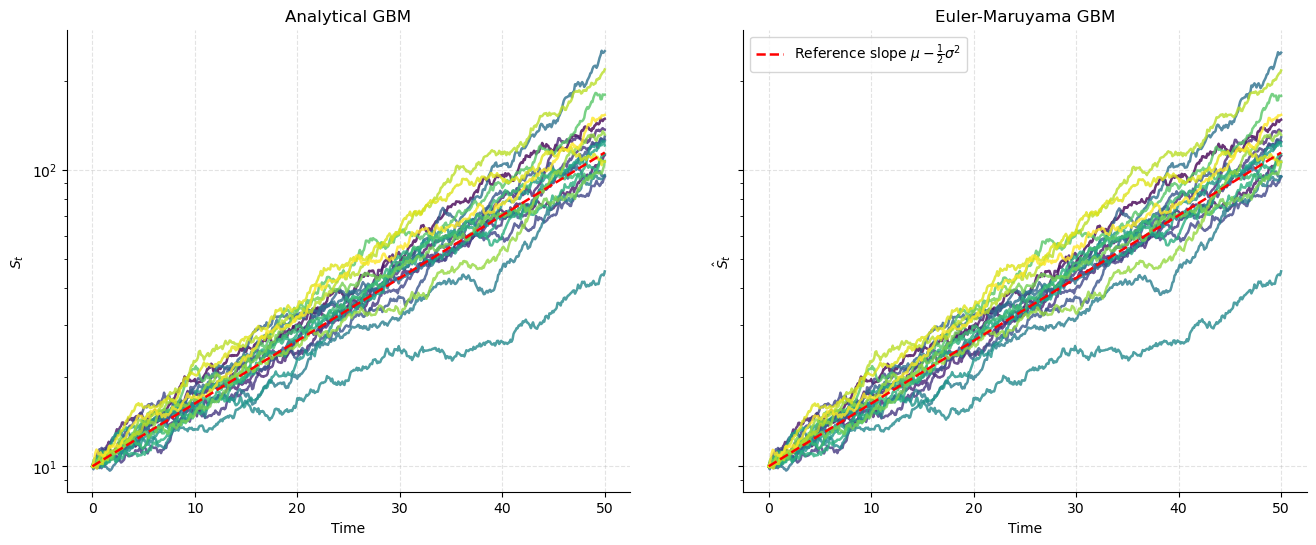

In [66]:
# Parameters
mu = 0.05
sigma = 0.05
S0 = 10
T = 50

dt = 0.1
n_sims = 20

# Auxiliary values
n_steps = int(T / dt)
W = np.random.normal(0, np.sqrt(dt), (n_sims, n_steps))
x = np.linspace(0, T, n_steps + 1)

St = analytical_GBM(mu, sigma, S0, T, W)
St_num = euler_maruyama_GBM(mu, sigma, S0, T, W)

ref = S0 * np.exp((mu - 0.5 * sigma**2)* x)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, n_sims))

# Analytical GBM
for i, color in enumerate(colors):
    axes[0].semilogy(x, St[i], color=color, alpha=0.8, linewidth=1.8)

axes[0].semilogy(x,ref,'--', color="r", alpha=1, linewidth=1.8)

axes[0].set_title("Analytical GBM")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("$S_t$")
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Euler-Maruyama GBM
for i, color in enumerate(colors):
    axes[1].semilogy(x, St_num[i], color=color, alpha=0.8, linewidth=1.8)

axes[1].semilogy(x,ref,'--', color="r", alpha=1, linewidth=1.8, label=r'Reference slope $\mu-\frac{1}{2}\sigma^2$')
plt.legend()

axes[1].set_title("Euler-Maruyama GBM")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("$\hat S_t$")
axes[1].grid(True, linestyle="--", alpha=0.35)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.show()

## Strong and weak error

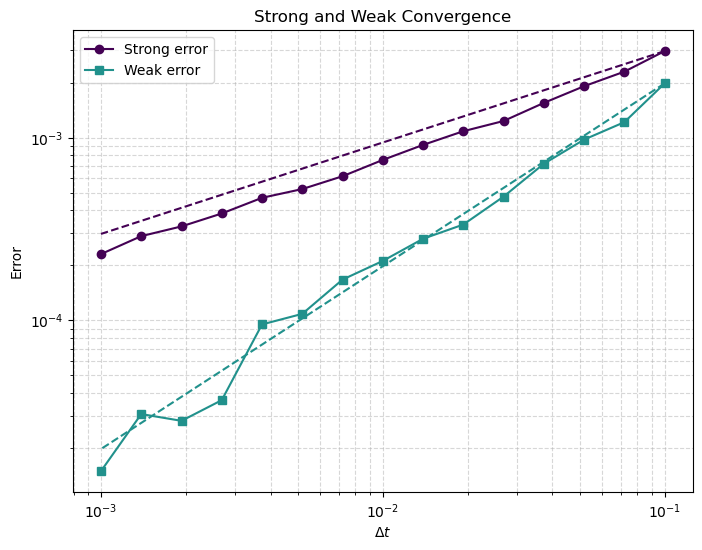

In [77]:
# Parameters
mu = 0.05
sigma = 0.05
S0 = 1
T = 10
n_sims = 1000

# Refinement parameters
start = 0.1
end = 0.001
reps = 15

dts = np.geomspace(start, end, reps)
strong_errors = np.zeros(reps)
weak_errors = np.zeros(reps)

# Calculate errors for each dt
for i, dt in enumerate(dts):
    n_steps = int(T / dt)

    W = np.random.normal(0, np.sqrt(dt), (n_sims, n_steps))

    strong_errors[i] = strong_error(mu, sigma, S0, T, W)
    weak_errors[i] = weak_error(mu, sigma, S0, T, W)

plt.figure(figsize=(8, 6))

colors = plt.cm.viridis(np.linspace(0, 1, 3))
strong_color, weak_color, _ = colors

plt.loglog(dts, strong_errors, 'o-', color=strong_color, label='Strong error')
plt.loglog(dts, weak_errors, 's-', color=weak_color, label='Weak error')

plt.xlabel(r'$\Delta t$')
plt.ylabel('Error')
plt.title('Strong and Weak Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

strong_ref = strong_errors[0] * (dts / dts[0])**0.5
weak_ref = weak_errors[0] * (dts / dts[0])**1.0

plt.loglog(dts, strong_ref, '--', color=strong_color, label=r'Reference slope $1/2$')
plt.loglog(dts, weak_ref, '--', color=weak_color, label=r'Reference slope $1$')

plt.show()